In [50]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from db_config import get_database_url
from sqlalchemy import create_engine


In [ ]:
engine = create_engine(get_database_url())
#camps_point_id = 6
df = pd.read_sql(
    "SELECT * FROM public.pollen_by_date_time",
    engine
)

df.head()

,fdate,ftime,analysis_time,alder_pollen,birch_pollen,grass_pollen,mugwort_pollen,olive_pollen,ragweed_pollen,pollen_total
0,2026-07-04,00:00:00,2026-07-04,0.0000000000,0.0000000000,45.7036132812,0.1615905762,0.0000000000,0.0000000000,45.8652038574
1,2026-07-04,01:00:00,2026-07-04,0.0000000000,0.0000000000,46.2576904297,0.2410583496,0.0000000000,0.0000000000,46.4987487793
2,2026-07-04,02:00:00,2026-07-04,0.0000000000,0.0000000000,43.6116333008,0.4202423096,0.0000000000,0.0000000000,44.0318756104
3,2026-07-04,03:00:00,2026-07-04,0.0000000000,0.0000000000,41.6278686523,0.4507141113,0.0000000000,0.0000000000,42.0785827637
4,2026-07-04,04:00:00,2026-07-04,0.0000000000,0.0000000000,36.9073486328,0.4502258301,0.0000000000,0.0000000000,37.3575744629


In [42]:
df = df.round(12)
df.head()

,fdate,ftime,analysis_time,alder_pollen,birch_pollen,grass_pollen,mugwort_pollen,olive_pollen,ragweed_pollen,pollen_total
0,2026-07-04,00:00:00,2026-07-04,0.0000000000,0.0000000000,45.7036132812,0.1615905762,0.0000000000,0.0000000000,45.8652038574
1,2026-07-04,01:00:00,2026-07-04,0.0000000000,0.0000000000,46.2576904297,0.2410583496,0.0000000000,0.0000000000,46.4987487793
2,2026-07-04,02:00:00,2026-07-04,0.0000000000,0.0000000000,43.6116333008,0.4202423096,0.0000000000,0.0000000000,44.0318756104
3,2026-07-04,03:00:00,2026-07-04,0.0000000000,0.0000000000,41.6278686523,0.4507141113,0.0000000000,0.0000000000,42.0785827637
4,2026-07-04,04:00:00,2026-07-04,0.0000000000,0.0000000000,36.9073486328,0.4502258301,0.0000000000,0.0000000000,37.3575744629


In [43]:
df['fdate'] = pd.to_datetime(df['fdate'], format='%Y-%m-%d')
df['ftime'] = pd.to_datetime(df['ftime'], format='%H:%M:%S').dt.time
df['analysis_time'] = pd.to_datetime(df['analysis_time'], format='%Y-%m-%d')
df.head()

,fdate,ftime,analysis_time,alder_pollen,birch_pollen,grass_pollen,mugwort_pollen,olive_pollen,ragweed_pollen,pollen_total
0,2026-07-04,00:00:00,2026-07-04,0.0000000000,0.0000000000,45.7036132812,0.1615905762,0.0000000000,0.0000000000,45.8652038574
1,2026-07-04,01:00:00,2026-07-04,0.0000000000,0.0000000000,46.2576904297,0.2410583496,0.0000000000,0.0000000000,46.4987487793
2,2026-07-04,02:00:00,2026-07-04,0.0000000000,0.0000000000,43.6116333008,0.4202423096,0.0000000000,0.0000000000,44.0318756104
3,2026-07-04,03:00:00,2026-07-04,0.0000000000,0.0000000000,41.6278686523,0.4507141113,0.0000000000,0.0000000000,42.0785827637
4,2026-07-04,04:00:00,2026-07-04,0.0000000000,0.0000000000,36.9073486328,0.4502258301,0.0000000000,0.0000000000,37.3575744629


In [45]:
df.dtypes

fdate             datetime64[s]
ftime                    object
analysis_time     datetime64[s]
alder_pollen            float64
birch_pollen            float64
grass_pollen            float64
mugwort_pollen          float64
olive_pollen            float64
ragweed_pollen          float64
pollen_total            float64
dtype: object

In [46]:
pd.set_option('display.float_format', '{:.10f}'.format)

In [53]:
df_grouped = df.groupby(['fdate'])[
    ['alder_pollen', 'birch_pollen', 'grass_pollen', 'mugwort_pollen', 'olive_pollen', 'ragweed_pollen', 'pollen_total']
].mean()
df_grouped.tail()

,alder_pollen,birch_pollen,grass_pollen,mugwort_pollen,olive_pollen,ragweed_pollen,pollen_total
fdate,,,,,,,
2026-06-30,0.0000960330,0.0050109227,47.3533471425,0.0108960470,0.0061728160,0.0000000261,47.3755231698
2026-07-01,0.0000058096,0.0033093294,24.2652931213,0.0022048950,0.0088202159,0.0000000038,24.2796333631
2026-07-02,0.0000238195,0.0021975835,25.1159661611,0.0206155777,0.0035876433,0.0000000218,25.1423906485
2026-07-03,0.0000003614,0.0000158946,31.8404191335,0.1503664653,0.0000324249,0.0000000002,31.9908343156
2026-07-04,0.0000000001,0.0000000000,35.3035125732,0.2684563001,0.0000000000,0.0000000000,35.5719688733


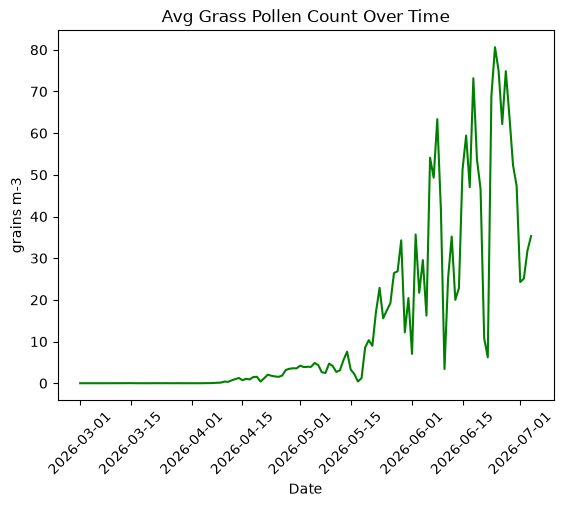

In [51]:
%matplotlib inline

plt.plot(df_grouped['grass_pollen'], color='g')
plt.title("Avg Grass Pollen Count Over Time")
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.ylabel("grains m-3")
plt.axis('tight');

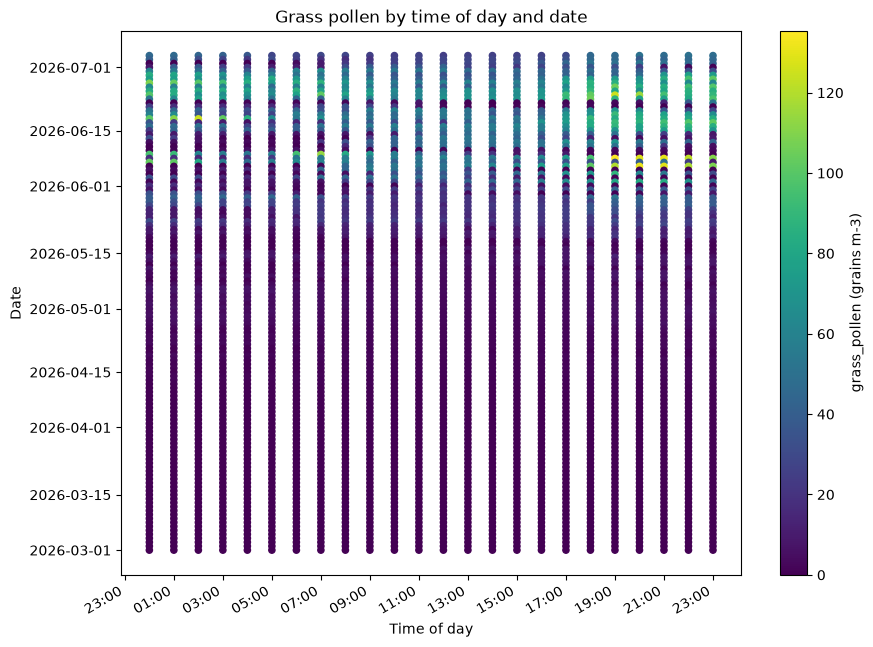

In [55]:
# Scatter plot: x = ftime (time of day), y = fdate (date), color = grass_pollen
import matplotlib.dates as mdates
ftimes = pd.to_datetime(df['ftime'].astype(str), format='%H:%M:%S', errors='coerce')
fdates = pd.to_datetime(df['fdate'])
plt.figure(figsize=(10,8))
sc = plt.scatter(ftimes, fdates, c=df['grass_pollen'], cmap='viridis', s=20)
plt.colorbar(sc, label='grass_pollen (grains m-3)')
plt.xlabel('Time of day')
plt.ylabel('Date')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.gcf().autofmt_xdate()
plt.title('Grass pollen by time of day and date')
plt.show()